# Heart Disease ML Pipeline

Notebook nay gom mot pipeline hoan chinh theo yeu cau 2.1 - 2.4:

- 2.1. Tien xu ly du lieu
- 2.2. Phan tich va truc quan hoa voi PCA, LDA
- 2.3. Phan cum DBSCAN sau giam chieu
- 2.4. Phan loai voi KNN, Logistic Regression, Linear SVM
- 2.4(c). Hoi quy tu score phan lop

## Cau hinh chung

In [168]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
DATA_PATH = "heart_2020_cleaned.csv"

# Gioi han mau de giam thoi gian va bo nho khi chay DBSCAN, KNN va ve bieu do.
DBSCAN_SAMPLE_SIZE = 50000
KNN_TRAIN_SAMPLE_SIZE = 50000
KNN_TEST_SAMPLE_SIZE = 15000
PLOT_SAMPLE_SIZE = 50000


## 2.1. Tien xu ly du lieu

### Doc du lieu va thong ke so bo

In [169]:
df_raw = pd.read_csv(DATA_PATH)

print("Kich thuoc ban dau:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())
display(df_raw.describe(include="all").T)

Kich thuoc ban dau: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDisease     319795 non-nu

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
HeartDisease,319795,2,No,292422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,319795.0,NaN,NaN,NaN,28.325399,6.3561,12.02,24.03,27.34,31.42,94.85
Smoking,319795,2,No,187887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AlcoholDrinking,319795,2,No,298018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroke,319795,2,No,307726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalHealth,319795.0,NaN,NaN,NaN,3.37171,7.95085,0.0,0.0,0.0,2.0,30.0
MentalHealth,319795.0,NaN,NaN,NaN,3.898366,7.955235,0.0,0.0,0.0,3.0,30.0
DiffWalking,319795,2,No,275385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,319795,2,Female,167805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AgeCategory,319795,13,65-69,34151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Truc quan hoa du lieu goc

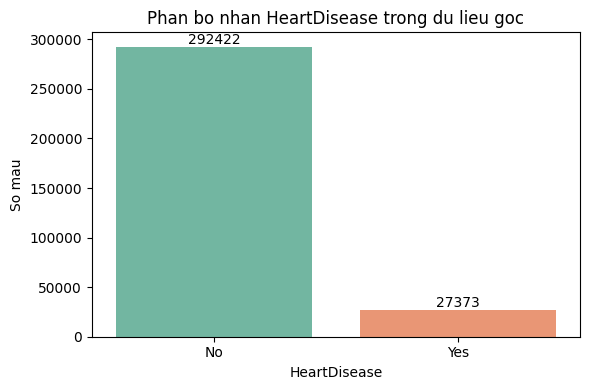

,ratio
HeartDisease,
No,0.914405
Yes,0.085595


In [170]:
# Phan bo nhan dau ra tren du lieu goc
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_raw, x="HeartDisease", palette="Set2")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Phan bo nhan HeartDisease trong du lieu goc")
plt.xlabel("HeartDisease")
plt.ylabel("So mau")
plt.tight_layout()
plt.show()

label_ratio_raw = df_raw["HeartDisease"].value_counts(normalize=True).rename("ratio").to_frame()
display(label_ratio_raw)

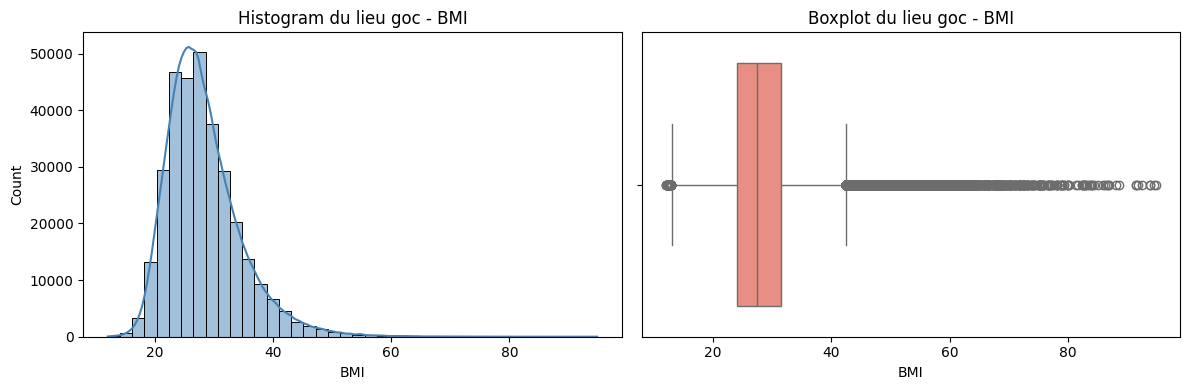

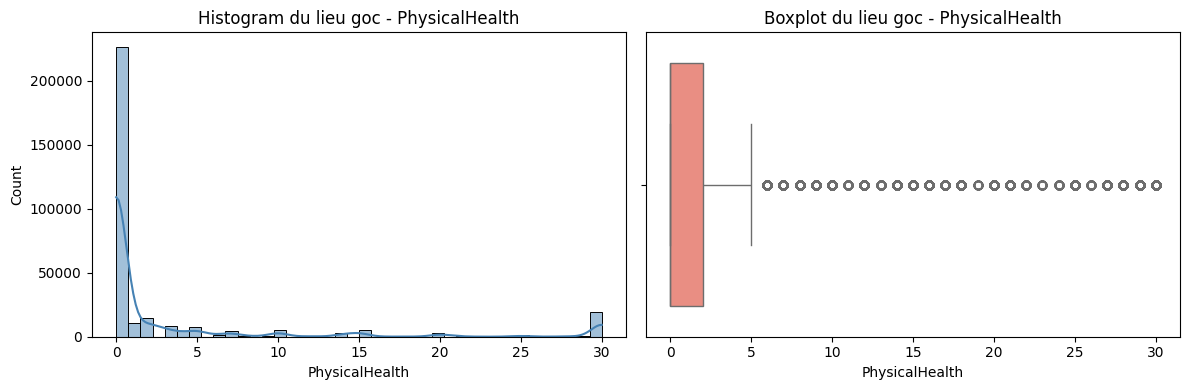

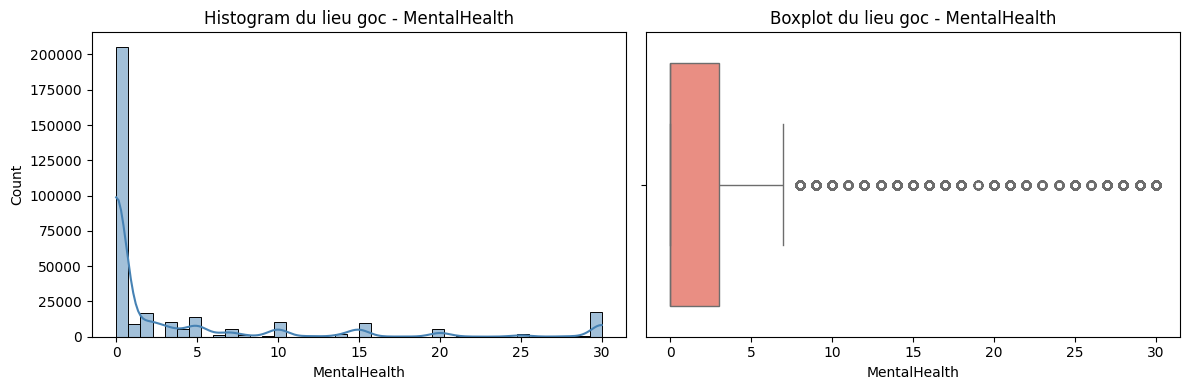

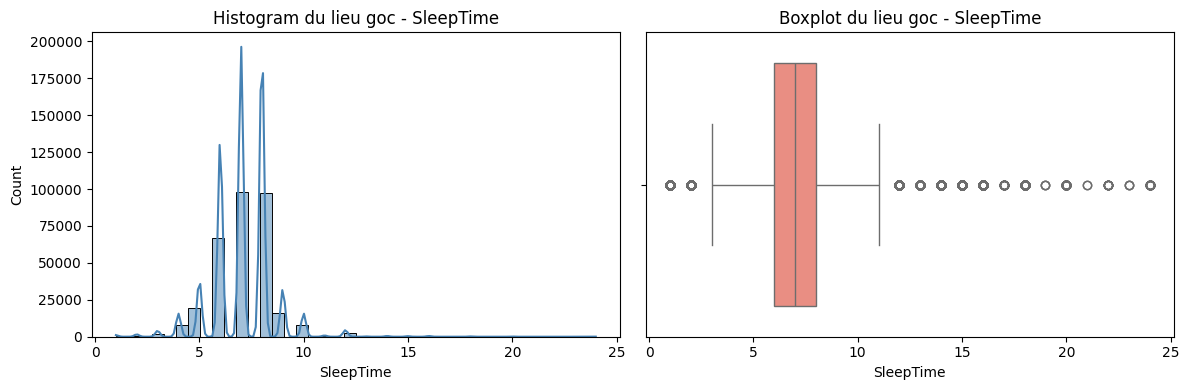

In [171]:
# Histogram va boxplot cho cac bien so truoc xu ly outlier
raw_num_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

for col in raw_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_raw[col], kde=True, bins=40, ax=axes[0], color="steelblue")
    axes[0].set_title(f"Histogram du lieu goc - {col}")
    sns.boxplot(x=df_raw[col], ax=axes[1], color="salmon")
    axes[1].set_title(f"Boxplot du lieu goc - {col}")
    plt.tight_layout()
    plt.show()

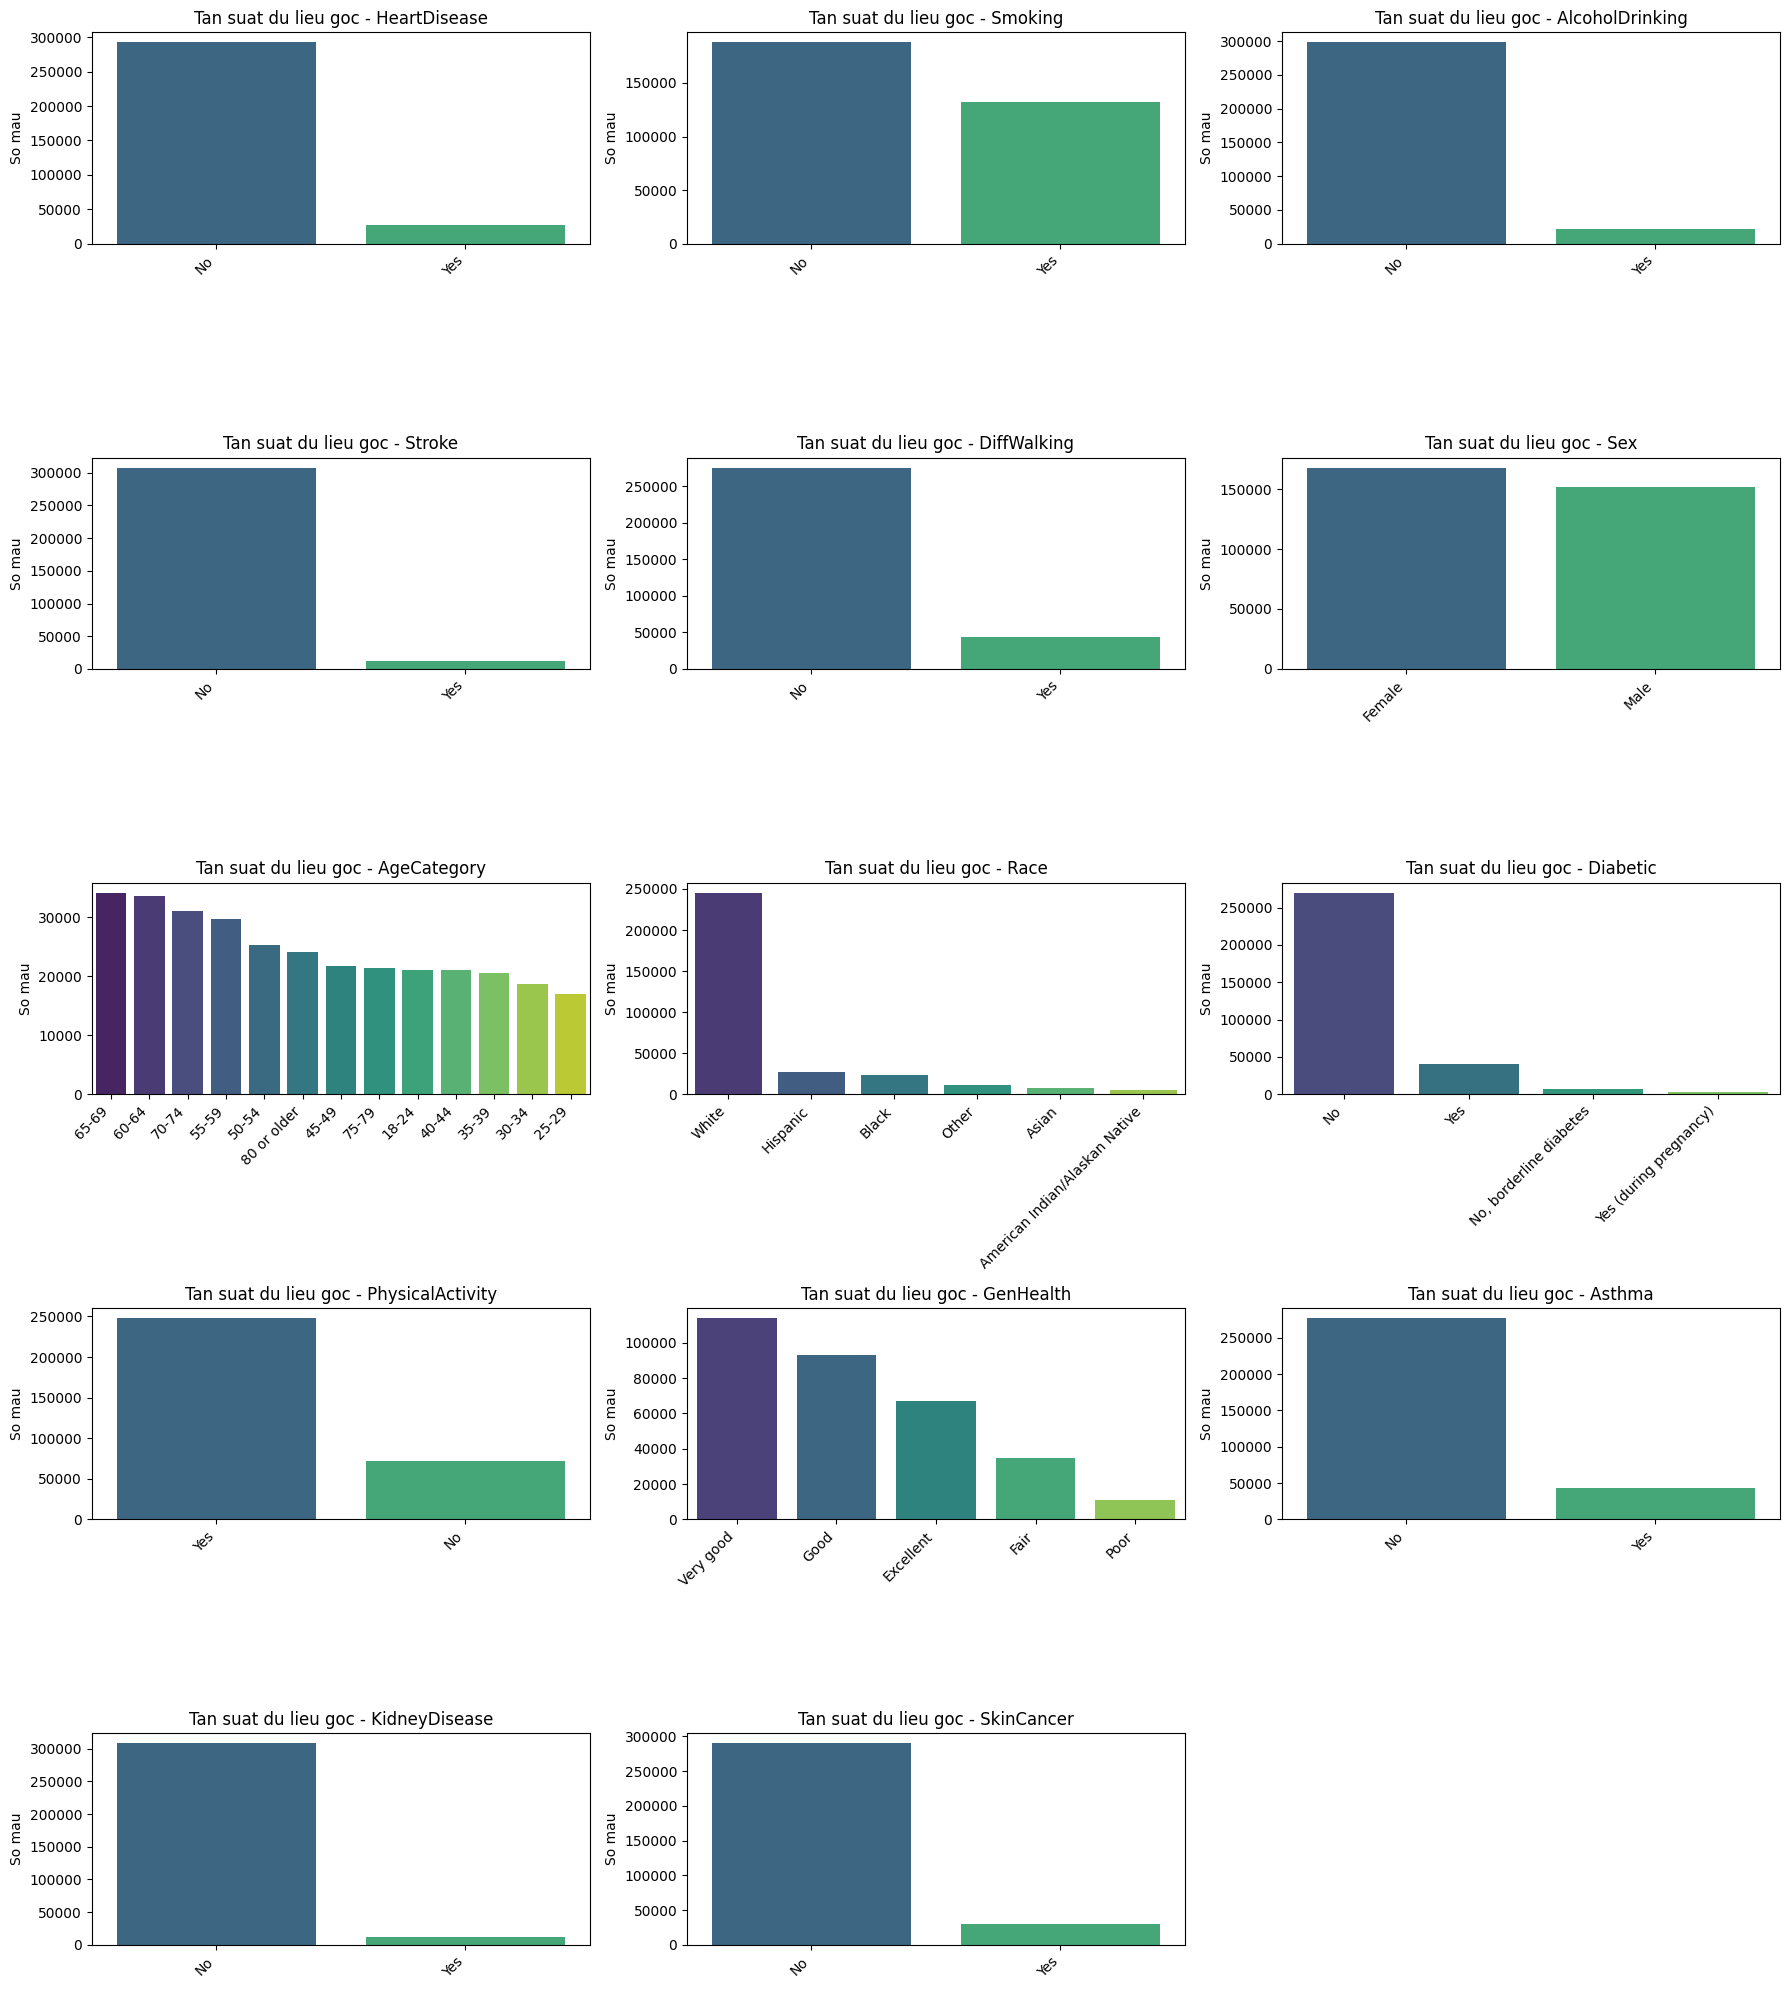

In [172]:
# Countplot cho cac bien phan loai tren du lieu goc
raw_cat_cols = [col for col in df_raw.columns if col not in raw_num_cols]

n_cols = 3
n_rows = int(np.ceil(len(raw_cat_cols) / n_cols))
plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(raw_cat_cols, start=1):
    plt.subplot(n_rows, n_cols, i)
    order = df_raw[col].value_counts().index
    sns.countplot(data=df_raw, x=col, order=order, palette="viridis")
    plt.title(f"Tan suat du lieu goc - {col}")
    plt.xlabel("")
    plt.ylabel("So mau")
    plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

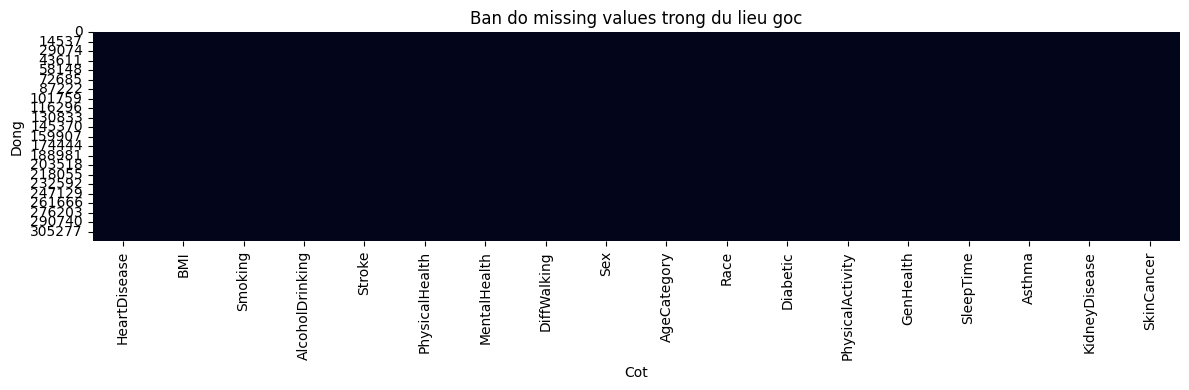

,metric,value
0,rows,319795
1,columns,18
2,duplicated_rows,18078
3,total_missing,0


In [173]:
# Heatmap missing values va bang duplicated tren du lieu goc
plt.figure(figsize=(12, 4))
sns.heatmap(df_raw.isna(), cbar=False)
plt.title("Ban do missing values trong du lieu goc")
plt.xlabel("Cot")
plt.ylabel("Dong")
plt.tight_layout()
plt.show()

raw_quality_summary = pd.DataFrame({
    "metric": ["rows", "columns", "duplicated_rows", "total_missing"],
    "value": [df_raw.shape[0], df_raw.shape[1], df_raw.duplicated().sum(), df_raw.isna().sum().sum()]
})
display(raw_quality_summary)

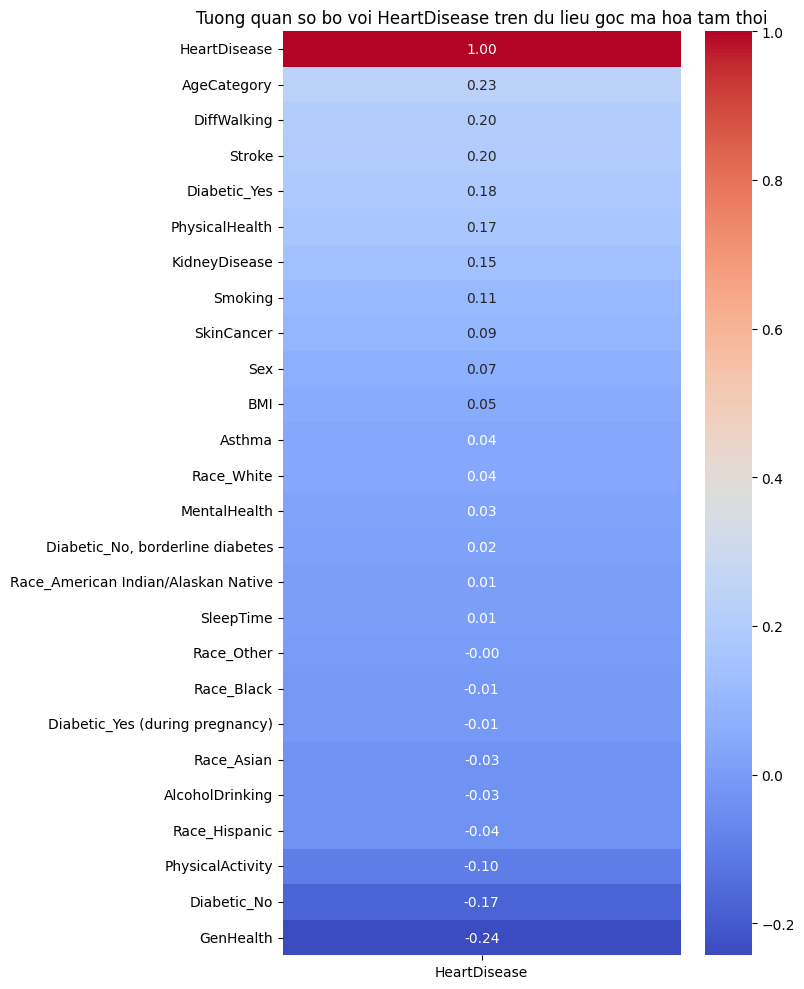

In [174]:
# Tuong quan so bo tren du lieu goc sau khi ma hoa tam thoi chi de truc quan hoa
df_raw_corr = df_raw.copy()

for col in [
    "HeartDisease", "Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
    "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"
]:
    df_raw_corr[col] = df_raw_corr[col].map({"No": 0, "Yes": 1})

df_raw_corr["Sex"] = df_raw_corr["Sex"].map({"Female": 0, "Male": 1})
df_raw_corr["AgeCategory"] = df_raw_corr["AgeCategory"].map({age: idx for idx, age in enumerate([
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79", "80 or older"
])})
df_raw_corr["GenHealth"] = df_raw_corr["GenHealth"].map({
    "Poor": 1, "Fair": 2, "Good": 3, "Very good": 4, "Excellent": 5
})
df_raw_corr = pd.get_dummies(df_raw_corr, columns=["Race", "Diabetic"], drop_first=False, dtype=int)

raw_corr = df_raw_corr.corr(numeric_only=True)
plt.figure(figsize=(8, 10))
sns.heatmap(
    raw_corr[["HeartDisease"]].sort_values("HeartDisease", ascending=False),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Tuong quan so bo voi HeartDisease tren du lieu goc ma hoa tam thoi")
plt.tight_layout()
plt.show()

### Kiem tra missing, trung lap va gia tri khong hop le

In [175]:
missing_summary = df_raw.isna().sum().rename("missing_count").to_frame()
missing_summary["missing_ratio"] = missing_summary["missing_count"] / len(df_raw)
display(missing_summary)

duplicate_count = df_raw.duplicated().sum()
print("So dong trung lap:", duplicate_count)

expected_values = {
    "HeartDisease": ["No", "Yes"],
    "Smoking": ["No", "Yes"],
    "AlcoholDrinking": ["No", "Yes"],
    "Stroke": ["No", "Yes"],
    "DiffWalking": ["No", "Yes"],
    "PhysicalActivity": ["No", "Yes"],
    "Asthma": ["No", "Yes"],
    "KidneyDisease": ["No", "Yes"],
    "SkinCancer": ["No", "Yes"],
    "Sex": ["Female", "Male"],
}

invalid_rows = []
for col, valid_values in expected_values.items():
    invalid_count = (~df_raw[col].isin(valid_values)).sum()
    invalid_rows.append({"column": col, "invalid_count": invalid_count})

invalid_summary = pd.DataFrame(invalid_rows)
display(invalid_summary)

,missing_count,missing_ratio
HeartDisease,0,0.0
BMI,0,0.0
Smoking,0,0.0
AlcoholDrinking,0,0.0
Stroke,0,0.0
PhysicalHealth,0,0.0
MentalHealth,0,0.0
DiffWalking,0,0.0
Sex,0,0.0
AgeCategory,0,0.0


So dong trung lap: 18078


,column,invalid_count
0,HeartDisease,0
1,Smoking,0
2,AlcoholDrinking,0
3,Stroke,0
4,DiffWalking,0
5,PhysicalActivity,0
6,Asthma,0
7,KidneyDisease,0
8,SkinCancer,0
9,Sex,0


### Xu ly trung lap va outlier

In [176]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Kich thuoc truoc khi xoa trung lap:", df_raw.shape)
print("So dong trung lap da xoa:", df_raw.duplicated().sum())
print("Kich thuoc sau khi xoa trung lap:", df.shape)

Kich thuoc truoc khi xoa trung lap: (319795, 18)
So dong trung lap da xoa: 18078
Kich thuoc sau khi xoa trung lap: (301717, 18)


In [177]:
# Mo ta thong ke du lieu sau khi xoa trung lap
print("Thong tin du lieu sau khi xoa trung lap:")
display(df.info())

print("Thong ke mo ta cac cot so:")
display(df.describe().T)

print("Thong ke mo ta tat ca cac cot:")
display(df.describe(include="all").T)

post_duplicate_summary = pd.DataFrame({
    "metric": ["rows", "columns", "duplicated_rows", "total_missing"],
    "value": [df.shape[0], df.shape[1], df.duplicated().sum(), df.isna().sum().sum()]
})
display(post_duplicate_summary)

print("Phan bo nhan HeartDisease sau khi xoa trung lap:")
display(df["HeartDisease"].value_counts().to_frame("count"))
display(df["HeartDisease"].value_counts(normalize=True).to_frame("ratio"))

Thong tin du lieu sau khi xoa trung lap:
<class 'pandas.DataFrame'>
RangeIndex: 301717 entries, 0 to 301716
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      301717 non-null  str    
 1   BMI               301717 non-null  float64
 2   Smoking           301717 non-null  str    
 3   AlcoholDrinking   301717 non-null  str    
 4   Stroke            301717 non-null  str    
 5   PhysicalHealth    301717 non-null  float64
 6   MentalHealth      301717 non-null  float64
 7   DiffWalking       301717 non-null  str    
 8   Sex               301717 non-null  str    
 9   AgeCategory       301717 non-null  str    
 10  Race              301717 non-null  str    
 11  Diabetic          301717 non-null  str    
 12  PhysicalActivity  301717 non-null  str    
 13  GenHealth         301717 non-null  str    
 14  SleepTime         301717 non-null  float64
 15  Asthma            301717 non-null  str

None

Thong ke mo ta cac cot so:


,count,mean,std,min,25%,50%,75%,max
BMI,301717.0,28.441970,6.468134,12.02,24.03,27.41,31.65,94.85
PhysicalHealth,301717.0,3.572298,8.140656,0.00,0.00,0.00,2.00,30.00
MentalHealth,301717.0,4.121475,8.128288,0.00,0.00,0.00,4.00,30.00
SleepTime,301717.0,7.084559,1.467122,1.00,6.00,7.00,8.00,24.00


Thong ke mo ta tat ca cac cot:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
HeartDisease,301717,2,No,274456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,301717.0,NaN,NaN,NaN,28.44197,6.468134,12.02,24.03,27.41,31.65,94.85
Smoking,301717,2,No,174312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AlcoholDrinking,301717,2,No,280136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroke,301717,2,No,289653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalHealth,301717.0,NaN,NaN,NaN,3.572298,8.140656,0.0,0.0,0.0,2.0,30.0
MentalHealth,301717.0,NaN,NaN,NaN,4.121475,8.128288,0.0,0.0,0.0,4.0,30.0
DiffWalking,301717,2,No,257362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,301717,2,Female,159671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AgeCategory,301717,13,65-69,31670,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,metric,value
0,rows,301717
1,columns,18
2,duplicated_rows,0
3,total_missing,0


Phan bo nhan HeartDisease sau khi xoa trung lap:


,count
HeartDisease,
No,274456
Yes,27261


,ratio
HeartDisease,
No,0.909647
Yes,0.090353


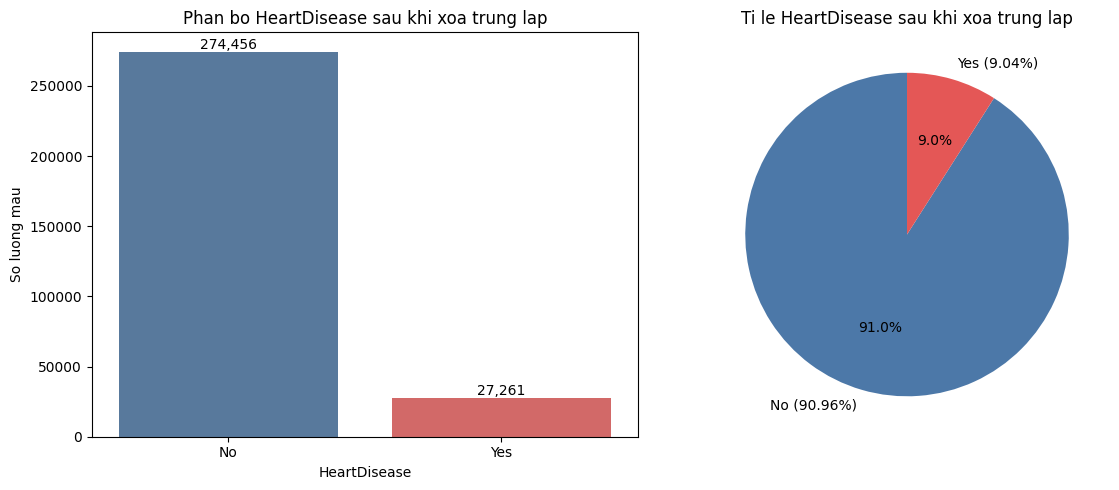

In [178]:
# Truc quan hoa bien HeartDisease sau khi xoa trung lap
heart_counts_after_dup = df["HeartDisease"].value_counts().reindex(["No", "Yes"])
heart_ratio_after_dup = (heart_counts_after_dup / heart_counts_after_dup.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    x=heart_counts_after_dup.index,
    y=heart_counts_after_dup.values,
    palette=["#4C78A8", "#E45756"],
    ax=axes[0]
)
axes[0].set_title("Phan bo HeartDisease sau khi xoa trung lap")
axes[0].set_xlabel("HeartDisease")
axes[0].set_ylabel("So luong mau")
for idx, value in enumerate(heart_counts_after_dup.values):
    axes[0].text(idx, value, f"{value:,}", ha="center", va="bottom")

axes[1].pie(
    heart_counts_after_dup.values,
    labels=[f"{label} ({heart_ratio_after_dup[label]}%)" for label in heart_counts_after_dup.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#E45756"],
    textprops={"fontsize": 10}
)
axes[1].set_title("Ti le HeartDisease sau khi xoa trung lap")

plt.tight_layout()
plt.show()


In [179]:
num_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

outlier_rows = []
df_before_capping = df.copy()
for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({
        "column": col,
        "lower_1pct": lower,
        "upper_99pct": upper,
        "outlier_count": int(mask.sum()),
        "outlier_ratio": float(mask.mean())
    })
    df[col] = df[col].clip(lower, upper)

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)
print("Tong so gia tri outlier:", outlier_summary["outlier_count"].sum())

,column,lower_1pct,upper_99pct,outlier_count,outlier_ratio
0,BMI,17.76,48.82,5966,0.019773
1,PhysicalHealth,0.00,30.00,0,0.000000
2,MentalHealth,0.00,30.00,0,0.000000
3,SleepTime,3.00,12.00,2338,0.007749


Tong so gia tri outlier: 8304


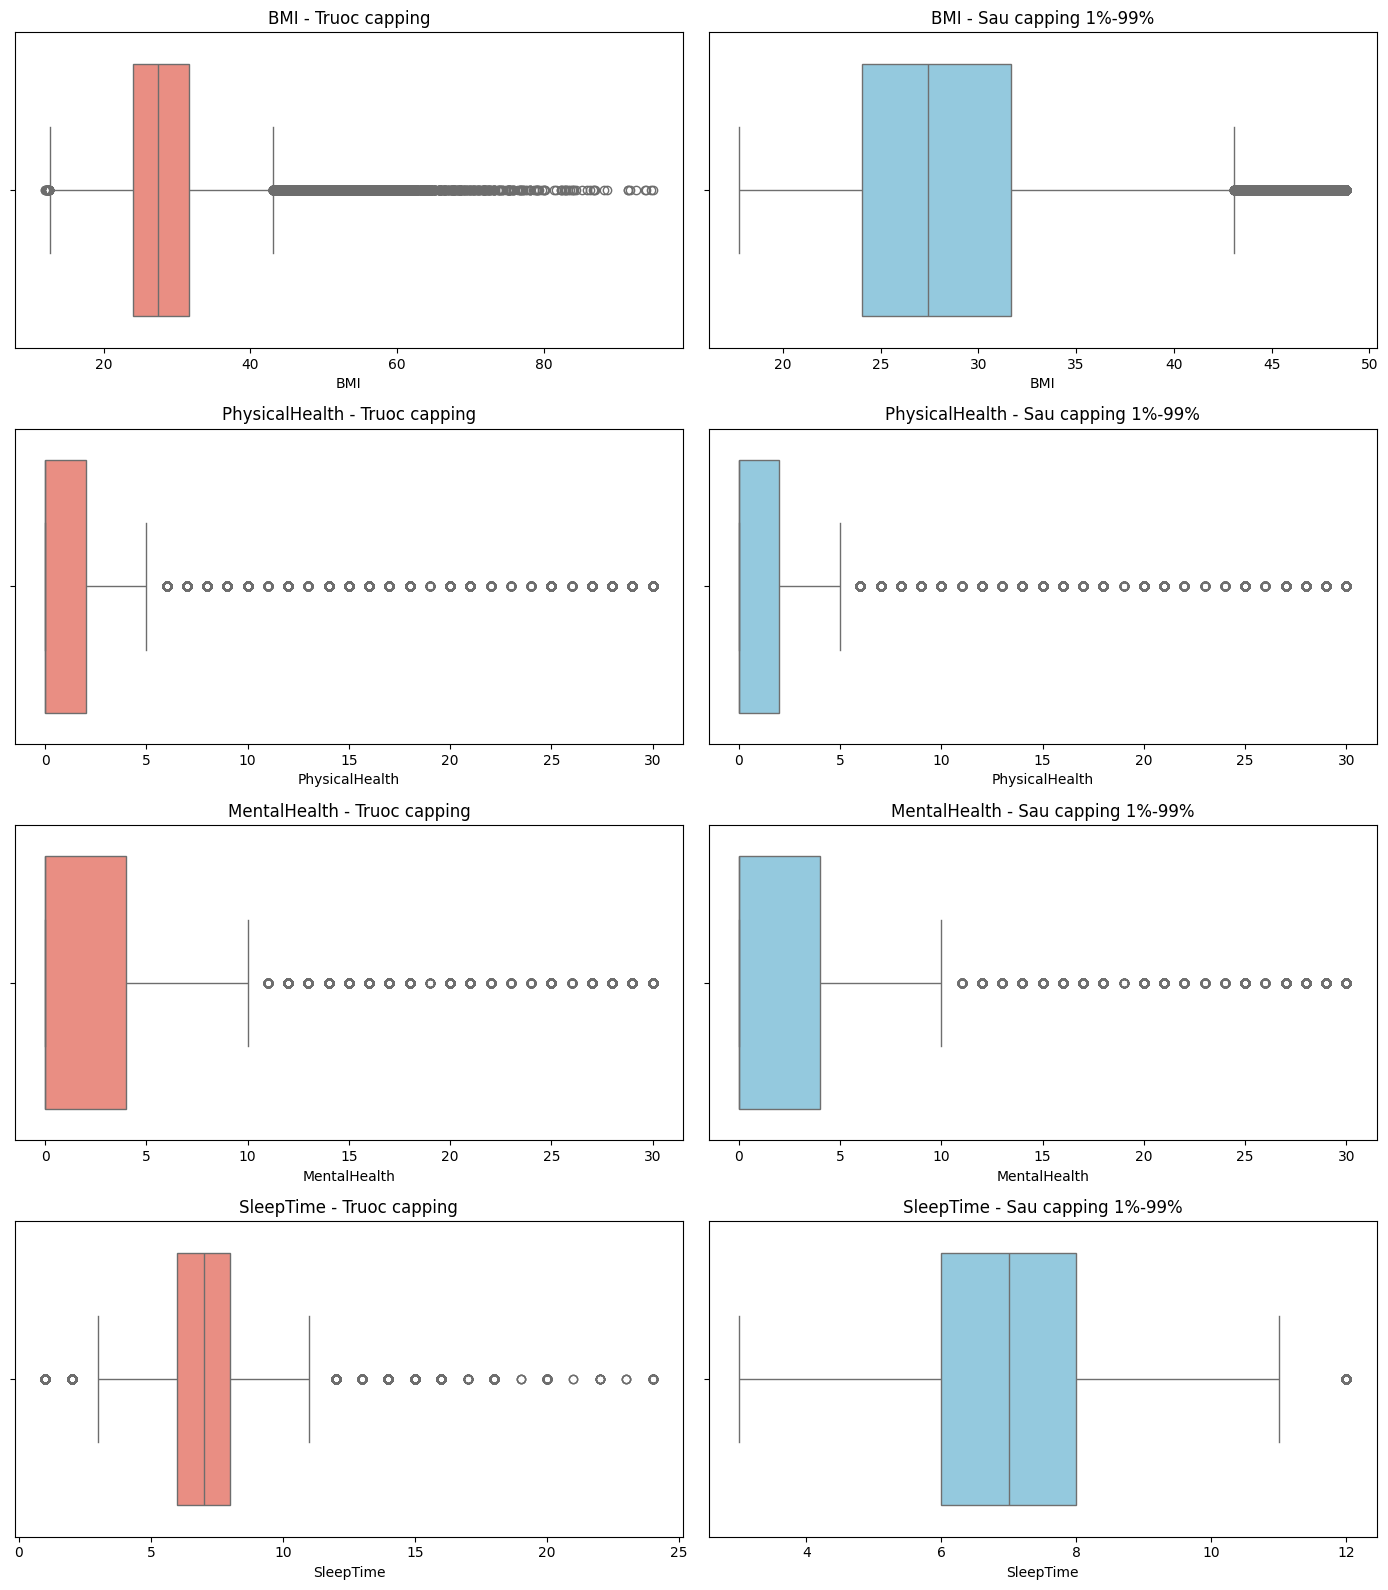

In [180]:
# Boxplot so sanh truoc va sau khi xu ly capping
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.boxplot(x=df_before_capping[col], ax=axes[i, 0], color="salmon")
    axes[i, 0].set_title(f"{col} - Truoc capping")
    axes[i, 0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[i, 1], color="skyblue")
    axes[i, 1].set_title(f"{col} - Sau capping 1%-99%")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Chia train/test truoc khi chuan hoa va ma hoa

In [181]:
# Pipeline tach ro thanh 2 phan:
# 1. Chia train/test khi X van giu dang goc sau capping.
# 2. Chuan hoa cac cot so tren train/test.
# 3. Sau do moi ma hoa bien nhi phan, thu bac va one-hot bien danh nghia.
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"].map({"No": 0, "Yes": 1})

splits = {
    "80/20": train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y),
    "70/30": train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y),
    "60/40": train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y),
}

for name, (X_train, X_test, y_train, y_test) in splits.items():
    print(name, "train:", X_train.shape, "test:", X_test.shape)

80/20 train: (241373, 17) test: (60344, 17)
70/30 train: (211201, 17) test: (90516, 17)
60/40 train: (181030, 17) test: (120687, 17)


### Buoc 1 - Chuan hoa rieng cac cot so

In [182]:
numeric_scale_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]


def scale_numeric_columns(X_train, X_test):
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    scaler = StandardScaler()
    X_train_scaled[numeric_scale_cols] = scaler.fit_transform(X_train_scaled[numeric_scale_cols])
    X_test_scaled[numeric_scale_cols] = scaler.transform(X_test_scaled[numeric_scale_cols])

    return X_train_scaled, X_test_scaled, scaler


scaled_splits = {}
for name, (X_train, X_test, y_train, y_test) in splits.items():
    X_train_scaled, X_test_scaled, scaler = scale_numeric_columns(X_train, X_test)
    scaled_splits[name] = {
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }
    print(name, "sau chuan hoa cot so:", X_train_scaled.shape, X_test_scaled.shape)

# Kiem tra nhanh mean/std cua cac cot so tren train 80/20
numeric_stats_after_scaling = scaled_splits["80/20"]["X_train_scaled"][numeric_scale_cols].agg(["mean", "std"]).T
display(numeric_stats_after_scaling)

80/20 sau chuan hoa cot so: (241373, 17) (60344, 17)
70/30 sau chuan hoa cot so: (211201, 17) (90516, 17)
60/40 sau chuan hoa cot so: (181030, 17) (120687, 17)


,mean,std
BMI,2.074758e-16,1.000002
PhysicalHealth,5.298757e-17,1.000002
MentalHealth,-2.531628e-17,1.000002
SleepTime,-2.025303e-17,1.000002


### Buoc 2 - Encode va one-hot cac cot du lieu khac

In [183]:
binary_feature_cols = [
    "Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
    "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"
]

age_order = [
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79", "80 or older"
]
age_map = {age: idx for idx, age in enumerate(age_order)}

gen_health_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very good": 4,
    "Excellent": 5
}

nominal_cols = ["Race", "Diabetic"]


def encode_after_scaling(X_train_scaled, X_test_scaled):
    X_train_encoded = X_train_scaled.copy()
    X_test_encoded = X_test_scaled.copy()

    # Encode Yes/No thanh 0/1
    for col in binary_feature_cols:
        X_train_encoded[col] = X_train_encoded[col].map({"No": 0, "Yes": 1})
        X_test_encoded[col] = X_test_encoded[col].map({"No": 0, "Yes": 1})

    # Encode bien nhi phan Sex
    X_train_encoded["Sex"] = X_train_encoded["Sex"].str.strip().map({"Female": 0, "Male": 1})
    X_test_encoded["Sex"] = X_test_encoded["Sex"].str.strip().map({"Female": 0, "Male": 1})

    # Encode bien thu bac
    X_train_encoded["AgeCategory"] = X_train_encoded["AgeCategory"].map(age_map)
    X_test_encoded["AgeCategory"] = X_test_encoded["AgeCategory"].map(age_map)

    X_train_encoded["GenHealth"] = X_train_encoded["GenHealth"].map(gen_health_map)
    X_test_encoded["GenHealth"] = X_test_encoded["GenHealth"].map(gen_health_map)

    # One-hot cac bien danh nghia khong co thu tu
    X_train_encoded = pd.get_dummies(
        X_train_encoded,
        columns=nominal_cols,
        drop_first=False,
        dtype=int
    )
    X_test_encoded = pd.get_dummies(
        X_test_encoded,
        columns=nominal_cols,
        drop_first=False,
        dtype=int
    )

    # Dam bao train/test co cung cot va thu tu cot
    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded,
        join="left",
        axis=1,
        fill_value=0
    )

    return X_train_encoded, X_test_encoded


processed_splits = {}
for name, split in scaled_splits.items():
    X_train_s, X_test_s = encode_after_scaling(
        split["X_train_scaled"],
        split["X_test_scaled"]
    )
    processed_splits[name] = {
        "X_train": X_train_s,
        "X_test": X_test_s,
        "y_train": split["y_train"],
        "y_test": split["y_test"],
        "scaler": split["scaler"],
    }
    print(name, "sau encode/one-hot:", X_train_s.shape, X_test_s.shape)

X_train_80_s = processed_splits["80/20"]["X_train"]
X_test_20_s = processed_splits["80/20"]["X_test"]
y_train_80 = processed_splits["80/20"]["y_train"]
y_test_20 = processed_splits["80/20"]["y_test"]

X_train_70_s = processed_splits["70/30"]["X_train"]
X_test_30_s = processed_splits["70/30"]["X_test"]
y_train_70 = processed_splits["70/30"]["y_train"]
y_test_30 = processed_splits["70/30"]["y_test"]

X_train_60_s = processed_splits["60/40"]["X_train"]
X_test_40_s = processed_splits["60/40"]["X_test"]
y_train_60 = processed_splits["60/40"]["y_train"]
y_test_40 = processed_splits["60/40"]["y_test"]

80/20 sau encode/one-hot: (241373, 25) (60344, 25)
70/30 sau encode/one-hot: (211201, 25) (90516, 25)
60/40 sau encode/one-hot: (181030, 25) (120687, 25)


### Mo ta du lieu sau chuan hoa

In [184]:
# Mo ta du lieu sau chuan hoa va ma hoa cho split 80/20
print("5 dong dau cua tap train sau chuan hoa va ma hoa:")
display(X_train_80_s.head())

# Bang thong ke rieng cho cac cot so da duoc chuan hoa.
# Yeu cau: cac bien la cac cot, cac thong ke la cac hang.
scaled_numeric_train = X_train_80_s[numeric_scale_cols]
scaled_numeric_test = X_test_20_s[numeric_scale_cols]

train_scaled_numeric_summary = scaled_numeric_train.agg(["mean", "std", "min", "max"]).round(4)
test_scaled_numeric_summary = scaled_numeric_test.agg(["mean", "std", "min", "max"]).round(4)

print("Thong ke cac cot so sau chuan hoa - Train 80/20")
display(train_scaled_numeric_summary)

print("Thong ke cac cot so sau chuan hoa - Test 20/80")
display(test_scaled_numeric_summary)

print("Kiem tra chat luong du lieu sau xu ly:")
print("Missing train/test:", int(X_train_80_s.isna().sum().sum()), int(X_test_20_s.isna().sum().sum()))
print("So cot object sau xu ly:", len(X_train_80_s.select_dtypes(include="object").columns))
print("So cot sau encode/one-hot:", X_train_80_s.shape[1])
print("Max abs mean cua 4 cot so da chuan hoa tren train:", float(np.abs(scaled_numeric_train.mean()).max()))

processed_overview = pd.DataFrame({
    "dataset": ["X_train_80_s", "X_test_20_s"],
    "rows": [X_train_80_s.shape[0], X_test_20_s.shape[0]],
    "columns": [X_train_80_s.shape[1], X_test_20_s.shape[1]],
    "missing_values": [int(X_train_80_s.isna().sum().sum()), int(X_test_20_s.isna().sum().sum())],
    "object_columns": [len(X_train_80_s.select_dtypes(include="object").columns), len(X_test_20_s.select_dtypes(include="object").columns)],
})
display(processed_overview)


5 dong dau cua tap train sau chuan hoa va ma hoa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
169471,0.505034,0,0,0,-0.439058,-0.137842,0,0,6,1,...,0,0,0,0,0,1,1,0,0,0
6968,-1.108526,0,0,0,-0.439058,-0.506526,0,0,9,1,...,0,0,0,0,0,1,1,0,0,0
199093,0.573007,1,0,0,1.277402,-0.506526,0,1,6,0,...,0,0,1,0,0,0,1,0,0,0
247108,-0.619765,0,0,0,-0.439058,-0.506526,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
45276,1.430767,1,0,0,0.051359,-0.506526,0,1,8,1,...,1,0,0,0,0,0,1,0,0,0


Thong ke cac cot so sau chuan hoa - Train 80/20


,BMI,PhysicalHealth,MentalHealth,SleepTime
mean,0.0000,0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000
min,-1.7203,-0.4391,-0.5065,-2.9618
max,3.3065,3.2391,3.1803,3.5760


Thong ke cac cot so sau chuan hoa - Test 20/80


,BMI,PhysicalHealth,MentalHealth,SleepTime
mean,0.0016,-0.0054,-0.0001,0.0031
std,1.0021,0.9903,0.9946,1.0029
min,-1.7203,-0.4391,-0.5065,-2.9618
max,3.3065,3.2391,3.1803,3.5760


Kiem tra chat luong du lieu sau xu ly:
Missing train/test: 0 0
So cot object sau xu ly: 0
So cot sau encode/one-hot: 25
Max abs mean cua 4 cot so da chuan hoa tren train: 2.074757823632795e-16


,dataset,rows,columns,missing_values,object_columns
0,X_train_80_s,241373,25,0,0
1,X_test_20_s,60344,25,0,0


## 2.2. Phan tich va truc quan hoa du lieu

### PCA: explained variance va thong ke thanh phan

,component,explained_variance,cumulative_variance
0,PC1,0.656127,0.656127
1,PC2,0.095778,0.751904
2,PC3,0.049746,0.801650
3,PC4,0.048421,0.850072
4,PC5,0.036917,0.886989
5,PC6,0.026552,0.913540
6,PC7,0.013832,0.927372
7,PC8,0.011673,0.939045
8,PC9,0.010761,0.949806
9,PC10,0.010004,0.959811


So PC can de giu >= 90% thong tin: 6


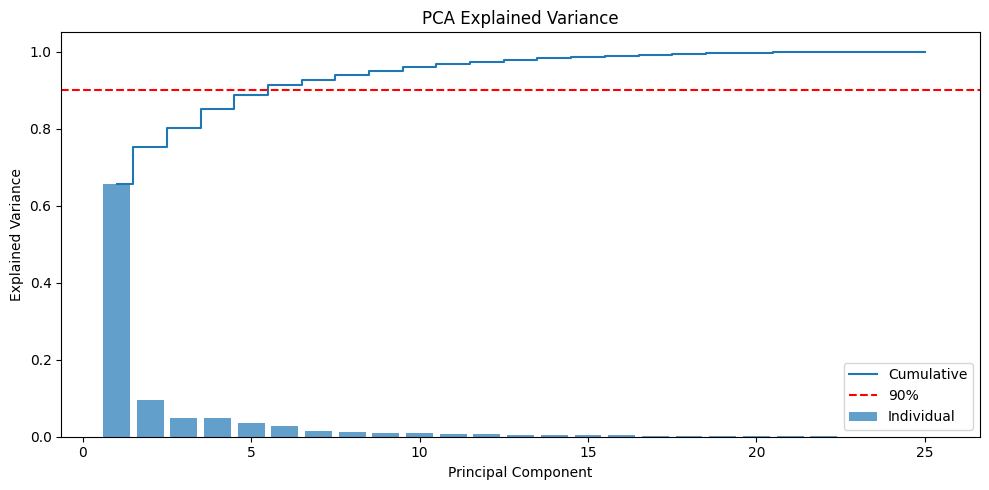

In [185]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_80_s)

pca_var = pca_full.explained_variance_ratio_
pca_cum = np.cumsum(pca_var)
pca_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_var))],
    "explained_variance": pca_var,
    "cumulative_variance": pca_cum
})
display(pca_table.head(15))

n_90 = int(np.argmax(pca_cum >= 0.90) + 1)
print("So PC can de giu >= 90% thong tin:", n_90)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca_var) + 1), pca_var, alpha=0.7, label="Individual")
plt.step(range(1, len(pca_cum) + 1), pca_cum, where="mid", label="Cumulative")
plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [186]:
pca_6 = PCA(n_components=6, random_state=RANDOM_STATE)
X_train_pca6 = pca_6.fit_transform(X_train_80_s)
X_test_pca6 = pca_6.transform(X_test_20_s)

pca6_df = pd.DataFrame(X_train_pca6, columns=[f"PC{i+1}" for i in range(6)])
pca6_df["HeartDisease"] = y_train_80.values

display(pca6_df.describe().T)
print("Tong explained variance PC1-PC6:", round(pca_6.explained_variance_ratio_.sum(), 4))

,count,mean,std,min,25%,50%,75%,max
PC1,241373.0,-1.120511e-15,3.602986,-6.876931,-2.634324,0.471252,2.680098,6.002200
PC2,241373.0,-2.576374e-16,1.376577,-6.581040,-0.537449,0.313732,0.937745,2.762294
PC3,241373.0,-1.030903e-16,0.992079,-4.349315,-0.616793,-0.057904,0.570878,4.590503
PC4,241373.0,-1.069171e-16,0.978786,-4.046541,-0.607246,-0.011379,0.552654,5.395968
PC5,241373.0,5.475382e-17,0.854637,-3.527019,-0.461654,-0.065891,0.347280,4.663149
PC6,241373.0,-1.778027e-16,0.724794,-2.780939,-0.517053,-0.020155,0.480741,4.041348
HeartDisease,241373.0,9.035393e-02,0.286689,0.000000,0.000000,0.000000,0.000000,1.000000


Tong explained variance PC1-PC6: 0.9135


### Truc quan hoa cac cap PC1-PC6

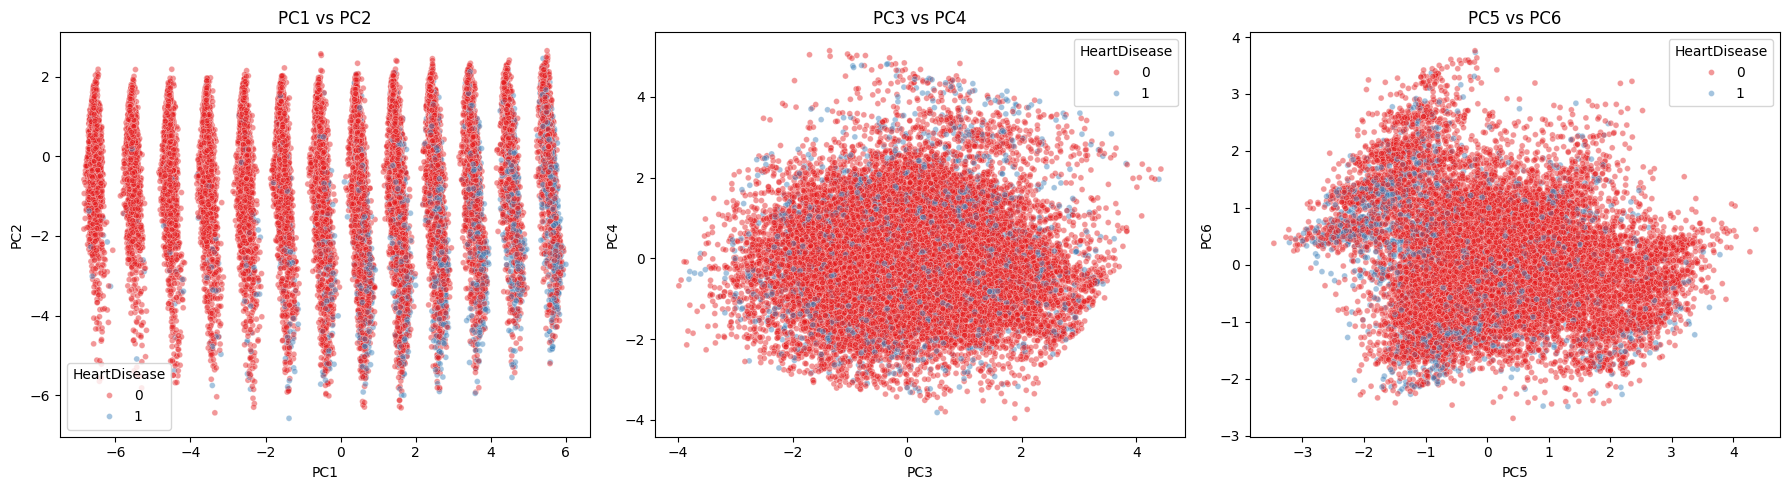

In [187]:
if PLOT_SAMPLE_SIZE is None or PLOT_SAMPLE_SIZE >= len(pca6_df):
    plot_df = pca6_df
else:
    plot_df = pca6_df.sample(PLOT_SAMPLE_SIZE, random_state=RANDOM_STATE)

pairs = [("PC1", "PC2"), ("PC3", "PC4"), ("PC5", "PC6")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(
        data=plot_df, x=x_col, y=y_col,
        hue="HeartDisease", palette="Set1",
        alpha=0.45, s=18, ax=ax
    )
    ax.set_title(f"{x_col} vs {y_col}")
plt.tight_layout()
plt.show()


### Quan he giua thanh phan chinh va dau ra

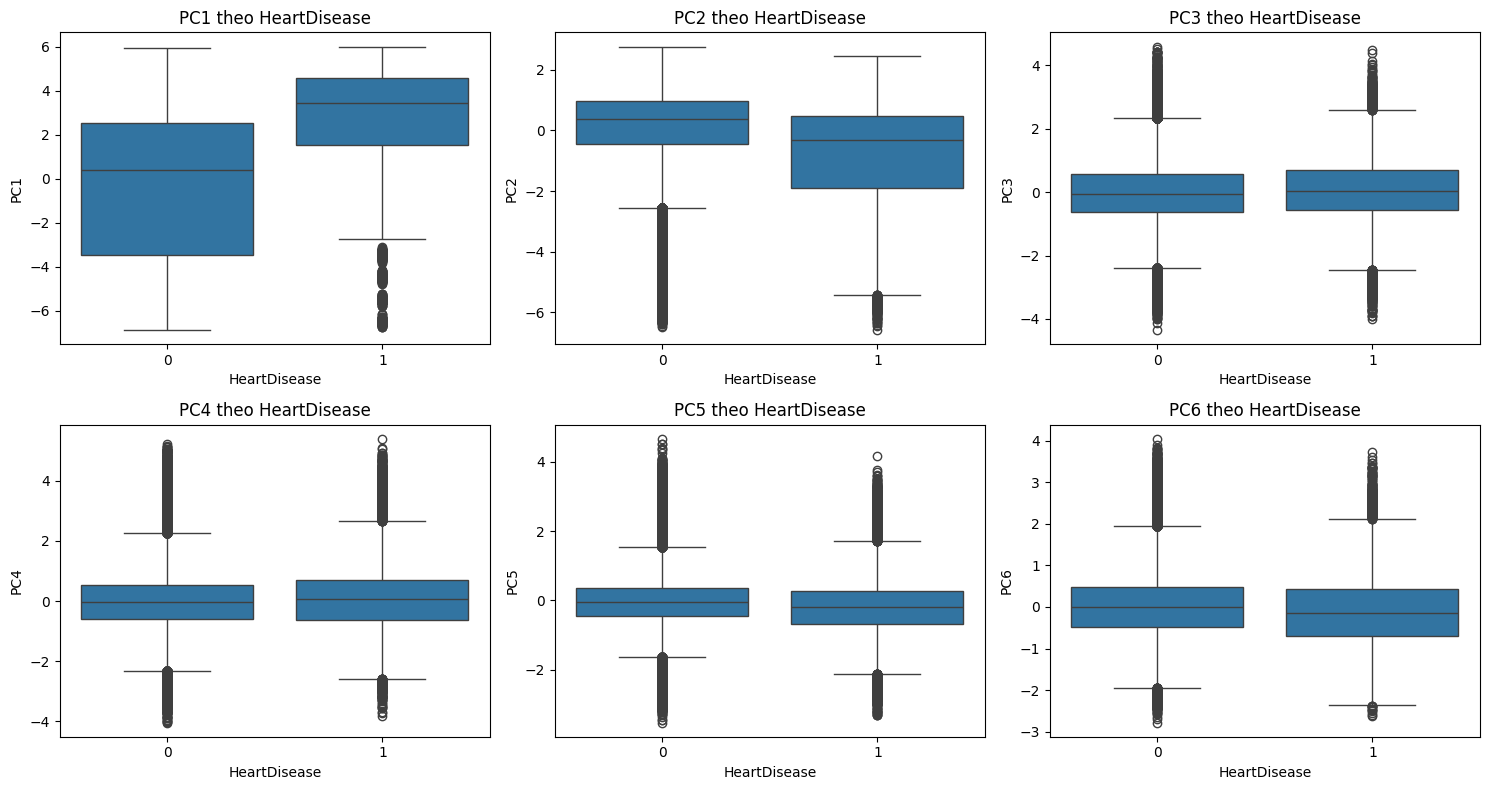

,corr_with_label
PC1,0.244606
PC2,-0.183689
PC5,-0.070091
PC6,-0.047352
PC4,0.034203
PC3,0.021431


In [188]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flatten(), start=1):
    sns.boxplot(data=pca6_df, x="HeartDisease", y=f"PC{i}", ax=ax)
    ax.set_title(f"PC{i} theo HeartDisease")
plt.tight_layout()
plt.show()

pca_label_corr = pca6_df.corr(numeric_only=True)["HeartDisease"].drop("HeartDisease")
display(pca_label_corr.sort_values(key=lambda x: x.abs(), ascending=False).to_frame("corr_with_label"))

### LDA: giam chieu co giam sat

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,219564.0,-0.127436,0.974252,-2.259983,-0.808465,-0.271606,0.38038,5.857989
1,21809.0,1.282970,1.229547,-2.195272,0.392767,1.063910,2.01547,5.972434


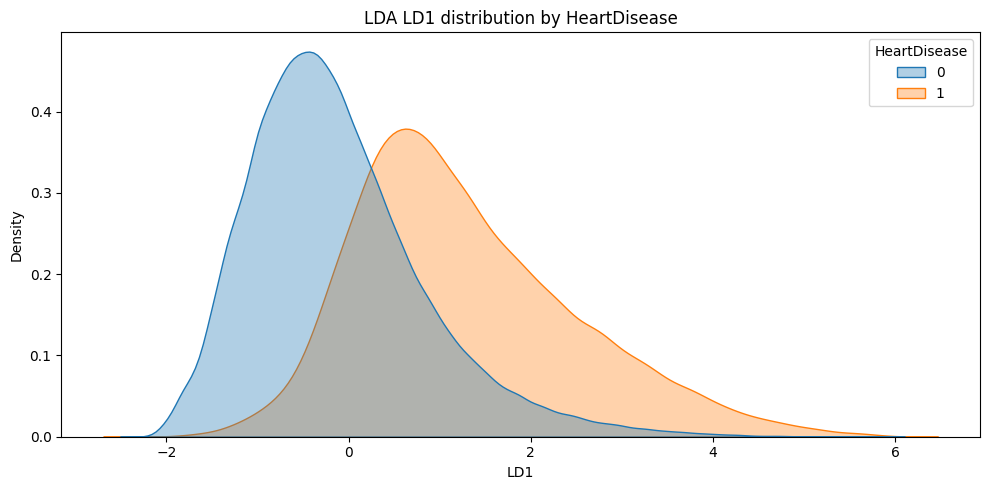

In [189]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_80_s, y_train_80)
X_test_lda = lda.transform(X_test_20_s)

lda_df = pd.DataFrame({"LD1": X_train_lda.ravel(), "HeartDisease": y_train_80.values})
display(lda_df.groupby("HeartDisease")["LD1"].describe())

plt.figure(figsize=(10, 5))
sns.kdeplot(data=lda_df, x="LD1", hue="HeartDisease", fill=True, common_norm=False, alpha=0.35)
plt.title("LDA LD1 distribution by HeartDisease")
plt.tight_layout()
plt.show()

### So sanh PCA va LDA

In [190]:
dimension_compare = pd.DataFrame([
    {
        "method": "PCA",
        "supervised": "No",
        "n_components_used": 6,
        "information_metric": "explained_variance_sum",
        "value": pca_6.explained_variance_ratio_.sum()
    },
    {
        "method": "PCA",
        "supervised": "No",
        "n_components_used": n_90,
        "information_metric": "components_for_90pct_variance",
        "value": n_90
    },
    {
        "method": "LDA",
        "supervised": "Yes",
        "n_components_used": 1,
        "information_metric": "class_separation_mean_diff",
        "value": abs(
            lda_df.loc[lda_df["HeartDisease"] == 1, "LD1"].mean()
            - lda_df.loc[lda_df["HeartDisease"] == 0, "LD1"].mean()
        )
    }
])
display(dimension_compare)

,method,supervised,n_components_used,information_metric,value
0,PCA,No,6,explained_variance_sum,0.913540
1,PCA,No,6,components_for_90pct_variance,6.000000
2,LDA,Yes,1,class_separation_mean_diff,1.410406


## 2.3. Phan cum du lieu bang DBSCAN

In [191]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X_cluster_all = pd.concat([X_train_80_s, X_test_20_s], axis=0)
y_cluster_all = pd.concat([y_train_80, y_test_20], axis=0).loc[X_cluster_all.index]

if DBSCAN_SAMPLE_SIZE is None or DBSCAN_SAMPLE_SIZE >= len(X_cluster_all):
    X_cluster_sample = X_cluster_all
    y_cluster_sample = y_cluster_all
else:
    sample_index, _ = train_test_split(
        X_cluster_all.index,
        train_size=DBSCAN_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_cluster_all
    )
    X_cluster_sample = X_cluster_all.loc[sample_index]
    y_cluster_sample = y_cluster_all.loc[sample_index]

pca_dbscan = PCA(n_components=2, random_state=RANDOM_STATE)
X_cluster_pca = pca_dbscan.fit_transform(X_cluster_sample)
X_cluster_pca = StandardScaler().fit_transform(X_cluster_pca)

print("DBSCAN data used:", X_cluster_sample.shape)
print("PCA 2D explained variance:", pca_dbscan.explained_variance_ratio_.round(4))


DBSCAN data used: (50000, 25)
PCA 2D explained variance: [0.6576 0.0946]


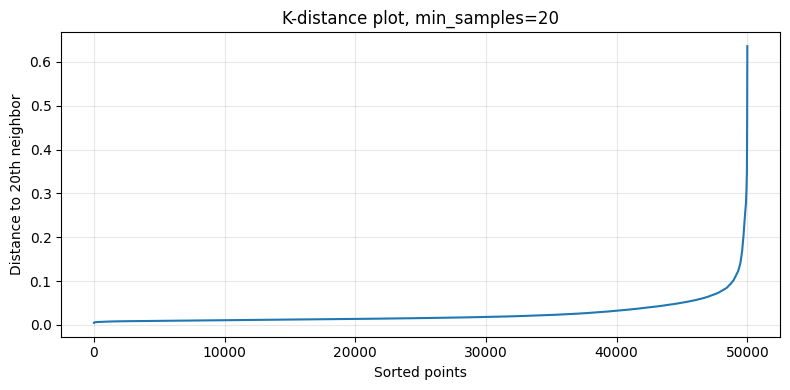

In [192]:
min_samples = 20
neighbors = NearestNeighbors(n_neighbors=min_samples)
distances, _ = neighbors.fit(X_cluster_pca).kneighbors(X_cluster_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f"K-distance plot, min_samples={min_samples}")
plt.xlabel("Sorted points")
plt.ylabel(f"Distance to {min_samples}th neighbor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [193]:
def cluster_purity(y_true, cluster_labels):
    valid = cluster_labels != -1
    if valid.sum() == 0:
        return np.nan
    y_valid = np.asarray(y_true)[valid]
    labels_valid = cluster_labels[valid]
    correct = 0
    for cluster_id in np.unique(labels_valid):
        counts = pd.Series(y_valid[labels_valid == cluster_id]).value_counts()
        correct += counts.max()
    return correct / len(y_valid)

def evaluate_dbscan_eps(X_values, y_true, eps_values, min_samples=20):
    rows = []
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_values)
        valid = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = float(np.mean(labels == -1))
        if n_clusters >= 2 and valid.sum() > n_clusters:
            sil = silhouette_score(X_values[valid], labels[valid])
            db = davies_bouldin_score(X_values[valid], labels[valid])
            ch = calinski_harabasz_score(X_values[valid], labels[valid])
        else:
            sil, db, ch = np.nan, np.nan, np.nan
        rows.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "ARI_vs_label": adjusted_rand_score(y_true, labels),
            "NMI_vs_label": normalized_mutual_info_score(y_true, labels),
            "purity_vs_label": cluster_purity(y_true, labels)
        })
    return pd.DataFrame(rows)

eps_values = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]
dbscan_eval = evaluate_dbscan_eps(X_cluster_pca, y_cluster_sample.values, eps_values, min_samples)
display(dbscan_eval.round(4))

candidates = dbscan_eval[
    (dbscan_eval["n_clusters"] >= 2)
    & (dbscan_eval["noise_ratio"] <= 0.60)
    & dbscan_eval["silhouette"].notna()
]
best_row = candidates.sort_values(["silhouette", "noise_ratio"], ascending=[False, True]).iloc[0] if len(candidates) else dbscan_eval.sort_values("noise_ratio").iloc[0]
best_eps = float(best_row["eps"])
print("Best eps:", best_eps)

,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_label,NMI_vs_label,purity_vs_label
0,0.15,20,3,0.0063,0.4926,0.4285,159.2067,0.0148,0.0025,0.9104
1,0.20,20,2,0.0031,0.5157,0.3659,233.4809,0.0035,0.0003,0.9098
2,0.25,20,1,0.0014,NaN,NaN,NaN,0.0018,0.0002,0.9097
3,0.30,20,1,0.0004,NaN,NaN,NaN,0.0005,0.0001,0.9097
4,0.35,20,1,0.0001,NaN,NaN,NaN,0.0006,0.0002,0.9097
5,0.40,20,1,0.0000,NaN,NaN,NaN,0.0003,0.0001,0.9097
6,0.50,20,1,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.9096
7,0.60,20,1,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.9096


Best eps: 0.2


,Cluster,count
0,Cluster 0,49813
1,Noise,155
2,Cluster 1,32


LabelName,No,Yes,All
ClusterName,,,
Cluster 0,45321,4492,49813
Cluster 1,29,3,32
Noise,132,23,155
All,45482,4518,50000


LabelName,No,Yes
ClusterName,,
Cluster 0,0.9098,0.0902
Cluster 1,0.9062,0.0938
Noise,0.8516,0.1484


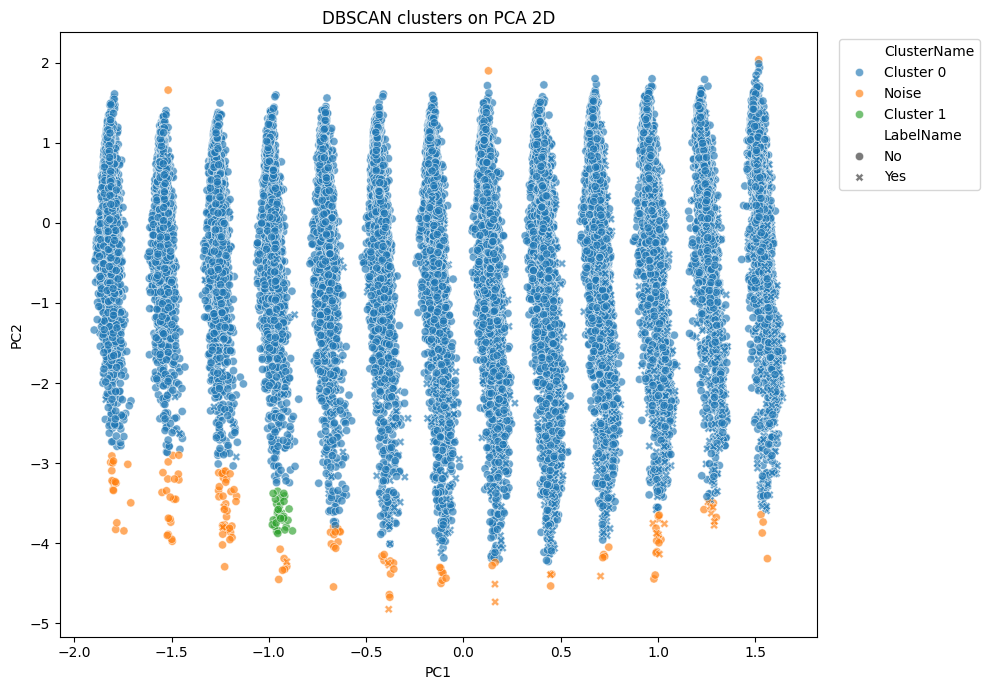

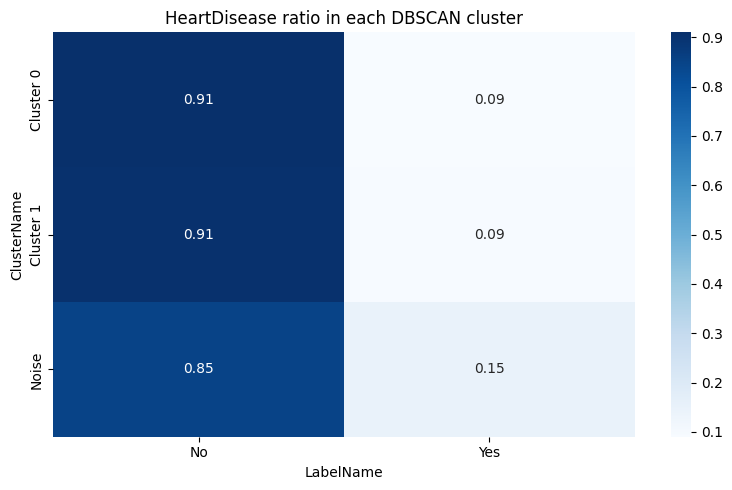

In [194]:
dbscan_labels = DBSCAN(eps=best_eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_cluster_pca)

cluster_df = pd.DataFrame(X_cluster_pca, columns=["PC1", "PC2"], index=X_cluster_sample.index)
cluster_df["HeartDisease"] = y_cluster_sample.values
cluster_df["LabelName"] = cluster_df["HeartDisease"].map({0: "No", 1: "Yes"})
cluster_df["Cluster"] = dbscan_labels
cluster_df["ClusterName"] = cluster_df["Cluster"].apply(lambda x: "Noise" if x == -1 else f"Cluster {x}")

cluster_counts = cluster_df["ClusterName"].value_counts().rename_axis("Cluster").reset_index(name="count")
display(cluster_counts)

cluster_label_table = pd.crosstab(cluster_df["ClusterName"], cluster_df["LabelName"], margins=True)
display(cluster_label_table)

cluster_label_ratio = pd.crosstab(cluster_df["ClusterName"], cluster_df["LabelName"], normalize="index").round(4)
display(cluster_label_ratio)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=cluster_df, x="PC1", y="PC2",
    hue="ClusterName", style="LabelName",
    alpha=0.65, s=35
)
plt.title("DBSCAN clusters on PCA 2D")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(cluster_label_ratio, annot=True, cmap="Blues", fmt=".2f")
plt.title("HeartDisease ratio in each DBSCAN cluster")
plt.tight_layout()
plt.show()

## 2.4. Phan loai

### Ham danh gia chung

In [195]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

def make_eval_sample(X_train, y_train, X_test, y_test, train_size=None, test_size=None):
    Xtr, ytr, Xte, yte = X_train, y_train, X_test, y_test
    if train_size is not None and len(Xtr) > train_size:
        idx, _ = train_test_split(Xtr.index, train_size=train_size, random_state=RANDOM_STATE, stratify=ytr)
        Xtr, ytr = Xtr.loc[idx], ytr.loc[idx]
    if test_size is not None and len(Xte) > test_size:
        idx, _ = train_test_split(Xte.index, train_size=test_size, random_state=RANDOM_STATE, stratify=yte)
        Xte, yte = Xte.loc[idx], yte.loc[idx]
    return Xtr, ytr, Xte, yte

def classifier_metrics(model_name, data_name, split_name, y_train, y_train_pred, y_train_score, y_test, y_pred, y_score):
    return {
        "Model": model_name,
        "Data": data_name,
        "Split": split_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Overfit Gap Acc": accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_pred),
        "Precision (Yes)": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Yes)": recall_score(y_test, y_pred, zero_division=0),
        "F1-score (Yes)": f1_score(y_test, y_pred, zero_division=0),
        "Train AUC": roc_auc_score(y_train, y_train_score),
        "Test AUC": roc_auc_score(y_test, y_score),
    }

def evaluate_classifier(model, model_name, data_name, split_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_train_score = model.predict_proba(X_train)[:, 1]
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_train_score = model.decision_function(X_train)
        y_score = model.decision_function(X_test)

    row = classifier_metrics(
        model_name, data_name, split_name,
        y_train, y_train_pred, y_train_score,
        y_test, y_pred, y_score
    )
    return model, y_pred, y_score, row

### Tao du lieu goc, PCA, LDA cho cac split

In [196]:
def make_pca_split(X_train, X_test, n_components=0.90):
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    return pca.fit_transform(X_train), pca.transform(X_test), pca

def make_lda_split(X_train, X_test, y_train):
    lda = LinearDiscriminantAnalysis(n_components=1)
    return lda.fit_transform(X_train, y_train), lda.transform(X_test), lda

classification_datasets = {}
for split_name, split in processed_splits.items():
    Xtr, Xte = split["X_train"], split["X_test"]
    ytr, yte = split["y_train"], split["y_test"]

    Xtr_pca, Xte_pca, pca_model = make_pca_split(Xtr, Xte, n_components=0.90)
    Xtr_lda, Xte_lda, lda_model = make_lda_split(Xtr, Xte, ytr)

    classification_datasets[(split_name, "RAW")] = (Xtr, Xte, ytr, yte)
    classification_datasets[(split_name, "PCA")] = (Xtr_pca, Xte_pca, ytr, yte)
    classification_datasets[(split_name, "LDA")] = (Xtr_lda, Xte_lda, ytr, yte)

### Chay KNN, Logistic Regression, Linear SVM

In [197]:
classification_results = []
trained_models = {}

for (split_name, data_name), (Xtr, Xte, ytr, yte) in classification_datasets.items():
    # KNN se dung toan bo train/test khi KNN_TRAIN_SAMPLE_SIZE va KNN_TEST_SAMPLE_SIZE la None.
    Xtr_knn, ytr_knn, Xte_knn, yte_knn = make_eval_sample(
        pd.DataFrame(Xtr, index=ytr.index) if not hasattr(Xtr, "index") else Xtr,
        ytr,
        pd.DataFrame(Xte, index=yte.index) if not hasattr(Xte, "index") else Xte,
        yte,
        train_size=KNN_TRAIN_SAMPLE_SIZE,
        test_size=KNN_TEST_SAMPLE_SIZE,
    )
    knn = KNeighborsClassifier(n_neighbors=15, weights="distance", metric="minkowski", p=2, n_jobs=-1)
    model, y_pred, y_score, row = evaluate_classifier(knn, "KNN", data_name, split_name, Xtr_knn, ytr_knn, Xte_knn, yte_knn)
    classification_results.append(row)
    trained_models[("KNN", split_name, data_name)] = model

    log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, penalty="l2", solver="lbfgs")
    model, y_pred, y_score, row = evaluate_classifier(log_reg, "Logistic Regression", data_name, split_name, Xtr, ytr, Xte, yte)
    classification_results.append(row)
    trained_models[("Logistic Regression", split_name, data_name)] = model

    svm = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)
    model, y_pred, y_score, row = evaluate_classifier(svm, "Linear SVM", data_name, split_name, Xtr, ytr, Xte, yte)
    classification_results.append(row)
    trained_models[("Linear SVM", split_name, data_name)] = model

classification_summary_df = pd.DataFrame(classification_results).round(4)
display(classification_summary_df)


,Model,Data,Split,Train Accuracy,Test Accuracy,Overfit Gap Acc,Precision (Yes),Recall (Yes),F1-score (Yes),Train AUC,Test AUC
0,KNN,RAW,80/20,0.9995,0.9045,0.0950,0.3194,0.0509,0.0878,1.0000,0.7690
1,Logistic Regression,RAW,80/20,0.7442,0.7431,0.0012,0.2275,0.7696,0.3512,0.8370,0.8324
2,Linear SVM,RAW,80/20,0.7389,0.7381,0.0009,0.2256,0.7808,0.3501,0.8369,0.8323
3,KNN,PCA,80/20,0.9995,0.9039,0.0955,0.3147,0.0539,0.0920,1.0000,0.7528
4,Logistic Regression,PCA,80/20,0.7122,0.7088,0.0033,0.2039,0.7650,0.3219,0.8122,0.8073
5,Linear SVM,PCA,80/20,0.7034,0.6996,0.0038,0.2003,0.7771,0.3186,0.8122,0.8073
6,KNN,LDA,80/20,0.9995,0.8882,0.1113,0.2646,0.1336,0.1775,1.0000,0.7417
7,Logistic Regression,LDA,80/20,0.7729,0.7732,-0.0002,0.2413,0.7043,0.3594,0.8300,0.8246
8,Linear SVM,LDA,80/20,0.7803,0.7800,0.0003,0.2447,0.6880,0.3610,0.8300,0.8246
9,KNN,RAW,70/30,0.9995,0.9049,0.0946,0.3435,0.0583,0.0997,1.0000,0.7633


### Truc quan hoa du doan - thuc te

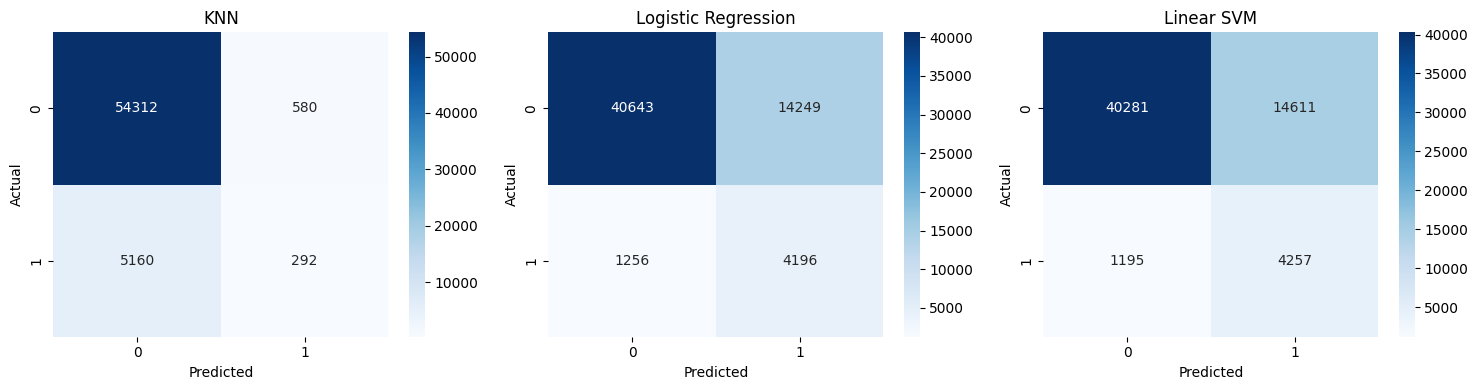

In [198]:
# Ve confusion matrix cho split 80/20, du lieu RAW.
Xtr_raw, Xte_raw, ytr_raw, yte_raw = classification_datasets[("80/20", "RAW")]

models_for_plot = {
    "KNN": trained_models[("KNN", "80/20", "RAW")],
    "Logistic Regression": trained_models[("Logistic Regression", "80/20", "RAW")],
    "Linear SVM": trained_models[("Linear SVM", "80/20", "RAW")],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, model) in zip(axes, models_for_plot.items()):
    Xte_plot, yte_plot = Xte_raw, yte_raw
    pred = model.predict(Xte_plot)
    cm = confusion_matrix(yte_plot, pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


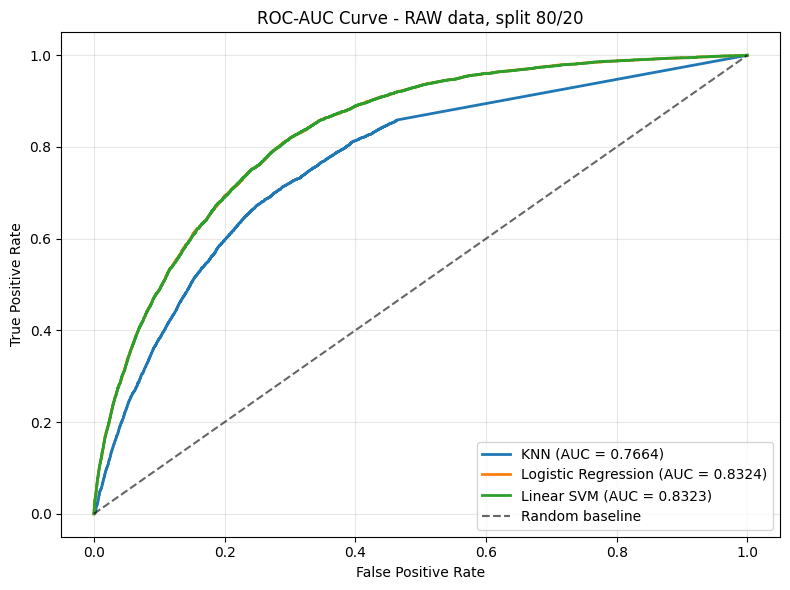

In [199]:
# Ve duong cong ROC-AUC cho cac mo hinh tren du lieu RAW, split 80/20
from sklearn.metrics import roc_curve, auc

Xtr_raw, Xte_raw, ytr_raw, yte_raw = classification_datasets[("80/20", "RAW")]

models_for_roc = {
    "KNN": trained_models[("KNN", "80/20", "RAW")],
    "Logistic Regression": trained_models[("Logistic Regression", "80/20", "RAW")],
    "Linear SVM": trained_models[("Linear SVM", "80/20", "RAW")],
}

plt.figure(figsize=(8, 6))
for model_name, model in models_for_roc.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(Xte_raw)[:, 1]
    else:
        y_score = model.decision_function(Xte_raw)

    fpr, tpr, _ = roc_curve(yte_raw, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - RAW data, split 80/20")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Nhan xet phan loai

In [200]:
best_by_auc = classification_summary_df.sort_values("Test AUC", ascending=False).head(10)
display(best_by_auc)

overfit_view = classification_summary_df.sort_values("Overfit Gap Acc", ascending=False).head(10)
display(overfit_view)

,Model,Data,Split,Train Accuracy,Test Accuracy,Overfit Gap Acc,Precision (Yes),Recall (Yes),F1-score (Yes),Train AUC,Test AUC
1,Logistic Regression,RAW,80/20,0.7442,0.7431,0.0012,0.2275,0.7696,0.3512,0.8370,0.8324
10,Logistic Regression,RAW,70/30,0.7449,0.7427,0.0021,0.2271,0.7689,0.3507,0.8377,0.8324
2,Linear SVM,RAW,80/20,0.7389,0.7381,0.0009,0.2256,0.7808,0.3501,0.8369,0.8323
11,Linear SVM,RAW,70/30,0.7397,0.7376,0.0021,0.2247,0.7773,0.3486,0.8375,0.8322
19,Logistic Regression,RAW,60/40,0.7461,0.7426,0.0035,0.2272,0.7694,0.3508,0.8388,0.8321
20,Linear SVM,RAW,60/40,0.7408,0.7370,0.0039,0.2240,0.7760,0.3477,0.8386,0.8320
25,Logistic Regression,LDA,60/40,0.7737,0.7717,0.0020,0.2406,0.7081,0.3591,0.8317,0.8248
26,Linear SVM,LDA,60/40,0.7810,0.7783,0.0027,0.2443,0.6945,0.3615,0.8317,0.8248
8,Linear SVM,LDA,80/20,0.7803,0.7800,0.0003,0.2447,0.6880,0.3610,0.8300,0.8246
16,Logistic Regression,LDA,70/30,0.7737,0.7722,0.0015,0.2405,0.7052,0.3587,0.8307,0.8246


,Model,Data,Split,Train Accuracy,Test Accuracy,Overfit Gap Acc,Precision (Yes),Recall (Yes),F1-score (Yes),Train AUC,Test AUC
24,KNN,LDA,60/40,0.9994,0.8858,0.1136,0.2528,0.1351,0.1760,1.0000,0.7389
6,KNN,LDA,80/20,0.9995,0.8882,0.1113,0.2646,0.1336,0.1775,1.0000,0.7417
15,KNN,LDA,70/30,0.9995,0.8892,0.1103,0.2923,0.1594,0.2063,1.0000,0.7407
3,KNN,PCA,80/20,0.9995,0.9039,0.0955,0.3147,0.0539,0.0920,1.0000,0.7528
0,KNN,RAW,80/20,0.9995,0.9045,0.0950,0.3194,0.0509,0.0878,1.0000,0.7690
18,KNN,RAW,60/40,0.9994,0.9046,0.0948,0.3155,0.0480,0.0833,1.0000,0.7617
9,KNN,RAW,70/30,0.9995,0.9049,0.0946,0.3435,0.0583,0.0997,1.0000,0.7633
12,KNN,PCA,70/30,0.9995,0.9050,0.0945,0.3077,0.0413,0.0729,1.0000,0.7430
21,KNN,PCA,60/40,0.9994,0.9064,0.0930,0.3600,0.0465,0.0824,1.0000,0.7497
20,Linear SVM,RAW,60/40,0.7408,0.7370,0.0039,0.2240,0.7760,0.3477,0.8386,0.8320


## 2.4(c). Hoi quy tu score phan lop

In [201]:
from sklearn.linear_model import LinearRegression, Ridge

Xtr, Xte, ytr, yte = classification_datasets[("80/20", "RAW")]

log_model = trained_models[("Logistic Regression", "80/20", "RAW")]
svm_model = trained_models[("Linear SVM", "80/20", "RAW")]

log_train_score = log_model.predict_proba(Xtr)[:, 1]
log_test_score = log_model.predict_proba(Xte)[:, 1]
svm_train_score = svm_model.decision_function(Xtr)
svm_test_score = svm_model.decision_function(Xte)

def make_one_third_pca(X_train, X_test):
    n_components = max(1, int(np.ceil(X_train.shape[1] / 3)))
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    return pca.fit_transform(X_train), pca.transform(X_test), pca

Xtr_13, Xte_13, pca_13 = make_one_third_pca(Xtr, Xte)
print("Original dimensions:", Xtr.shape[1])
print("1/3 PCA dimensions:", Xtr_13.shape[1])
print("Explained variance 1/3 PCA:", round(pca_13.explained_variance_ratio_.sum(), 4))

def evaluate_regressors(X_train, X_test, y_train_score, y_test_score, target_name, data_name):
    regressors = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0),
    }
    rows = []
    preds = {}
    for name, reg in regressors.items():
        reg.fit(X_train, y_train_score)
        pred = reg.predict(X_test)
        preds[(target_name, data_name, name)] = pred
        rows.append({
            "Target score": target_name,
            "Input data": data_name,
            "Regressor": name,
            "MAE": mean_absolute_error(y_test_score, pred),
            "RMSE": mean_squared_error(y_test_score, pred) ** 0.5,
            "R2": r2_score(y_test_score, pred),
        })
    return rows, preds

regression_rows = []
regression_preds = {}
for target_name, train_score, test_score in [
    ("Logistic probability score", log_train_score, log_test_score),
    ("Linear SVM decision score", svm_train_score, svm_test_score),
]:
    rows, preds = evaluate_regressors(Xtr, Xte, train_score, test_score, target_name, "Original processed features")
    regression_rows.extend(rows)
    regression_preds.update(preds)

    rows, preds = evaluate_regressors(Xtr_13, Xte_13, train_score, test_score, target_name, "PCA 1/3 dimensions")
    regression_rows.extend(rows)
    regression_preds.update(preds)

regression_score_df = pd.DataFrame(regression_rows).round(4)
display(regression_score_df)


Original dimensions: 25
1/3 PCA dimensions: 9
Explained variance 1/3 PCA: 0.9498


,Target score,Input data,Regressor,MAE,RMSE,R2
0,Logistic probability score,Original processed features,Linear Regression,0.0461,0.0566,0.9548
1,Logistic probability score,Original processed features,Ridge Regression,0.0461,0.0566,0.9548
2,Logistic probability score,PCA 1/3 dimensions,Linear Regression,0.0635,0.0824,0.9042
3,Logistic probability score,PCA 1/3 dimensions,Ridge Regression,0.0635,0.0824,0.9042
4,Linear SVM decision score,Original processed features,Linear Regression,0.0000,0.0000,1.0000
5,Linear SVM decision score,Original processed features,Ridge Regression,0.0000,0.0000,1.0000
6,Linear SVM decision score,PCA 1/3 dimensions,Linear Regression,0.0788,0.1171,0.9587
7,Linear SVM decision score,PCA 1/3 dimensions,Ridge Regression,0.0788,0.1171,0.9587


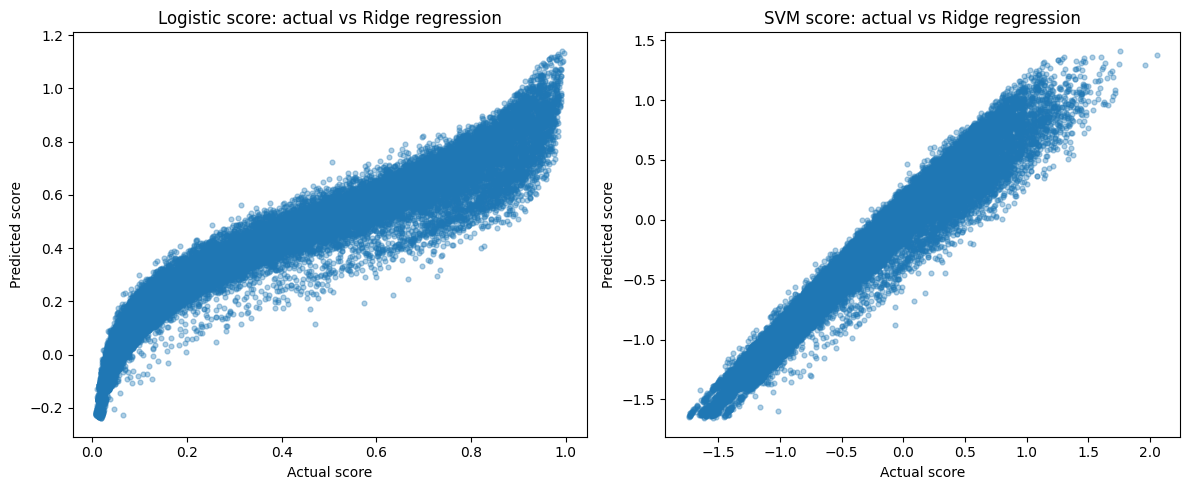

In [202]:
if PLOT_SAMPLE_SIZE is None or PLOT_SAMPLE_SIZE >= len(Xte):
    plot_idx = np.arange(len(Xte))
else:
    plot_idx = np.random.default_rng(RANDOM_STATE).choice(len(Xte), size=PLOT_SAMPLE_SIZE, replace=False)

ridge_log_pred = regression_preds[("Logistic probability score", "PCA 1/3 dimensions", "Ridge Regression")]
ridge_svm_pred = regression_preds[("Linear SVM decision score", "PCA 1/3 dimensions", "Ridge Regression")]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(log_test_score[plot_idx], ridge_log_pred[plot_idx], alpha=0.35, s=12)
axes[0].set_title("Logistic score: actual vs Ridge regression")
axes[0].set_xlabel("Actual score")
axes[0].set_ylabel("Predicted score")

axes[1].scatter(svm_test_score[plot_idx], ridge_svm_pred[plot_idx], alpha=0.35, s=12)
axes[1].set_title("SVM score: actual vs Ridge regression")
axes[1].set_xlabel("Actual score")
axes[1].set_ylabel("Predicted score")

plt.tight_layout()
plt.show()


## Ket luan ngan

- Pipeline da xu ly du lieu loi, ma hoa, chuan hoa va mo ta du lieu sau chuan hoa.
- PCA va LDA duoc dung de phan tich giam chieu va truc quan hoa.
- DBSCAN duoc thuc hien tren du lieu dau vao sau khi bo truong dau ra; nhan chi dung de danh gia quan he cum-nhan.
- Phan loai gom 03 nhom: KNN, Logistic Regression va Linear SVM.
- Hoi quy score dung 02 mo hinh: Linear Regression va Ridge Regression, tren du lieu goc va PCA 1/3 so chieu.
